### 라이브러리 import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

### 1단계: 데이터 탐색 및 문제 진단 (Data Exploration)

In [8]:
pima_columns = ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness',
                'insulin', 'bmi', 'diabetes_pedigree_function', 'age', 'outcome']
pima_data_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'

# names 파라미터를 사용하여 컬럼명 지정
df = pd.read_csv(pima_data_url, names=pima_columns)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   pregnancies                 768 non-null    int64  
 1   glucose                     768 non-null    int64  
 2   blood_pressure              768 non-null    int64  
 3   skin_thickness              768 non-null    int64  
 4   insulin                     768 non-null    int64  
 5   bmi                         768 non-null    float64
 6   diabetes_pedigree_function  768 non-null    float64
 7   age                         768 non-null    int64  
 8   outcome                     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
display(df.describe())

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 2단계: 결측치 처리 (Handling Missing Values)

In [11]:
# 0이 될 수 없는 피처 목록 (변경된 컬럼명 적용)
feature_columns = ['glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi']

# 1. '0' 값을 NaN으로 변환
print(f"변환 전 '0' 개수:\n{ (df[feature_columns] == 0).sum() }")
df[feature_columns] = df[feature_columns].replace(0, np.nan)

변환 전 '0' 개수:
glucose             5
blood_pressure     35
skin_thickness    227
insulin           374
bmi                11
dtype: int64


In [12]:
# 2. 평균값으로 NaN 대치 (Imputation)
imputer = SimpleImputer(strategy='mean')
df[feature_columns] = imputer.fit_transform(df[feature_columns])

print(f"\n대치(Imputation) 후 결측치 개수:\n{df[feature_columns].isnull().sum()}")


대치(Imputation) 후 결측치 개수:
glucose           0
blood_pressure    0
skin_thickness    0
insulin           0
bmi               0
dtype: int64


### 3단계: 스케일 조정 (Scaling)

In [13]:
# outcome을 제외한 특성 데이터 선택
X = df.drop('outcome', axis=1)

# StandardScaler 객체 생성 및 적용
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 보기 쉽게 DataFrame으로 변환
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("스케일링 후 통계 요약 (평균은 0, 표준편차는 1에 근사):")
display(X_scaled_df.describe().round(2))

스케일링 후 통계 요약 (평균은 0, 표준편차는 1에 근사):


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.14,-2.55,-4.00,-2.52,-1.67,-2.08,-1.19,-1.04
25%,-0.84,-0.72,-0.70,-0.47,-0.40,-0.72,-0.69,-0.79
50%,-0.25,-0.15,-0.02,0.00,-0.00,-0.01,-0.30,-0.36
75%,0.64,0.61,0.63,0.32,-0.00,0.60,0.47,0.66
max,3.91,2.54,4.10,7.95,8.13,5.04,5.88,4.06


### 4단계: 범주형 인코딩 (Categorical Encoding)

In [15]:
# 1. 'age' 피처로 'age_group' 생성 (Binning)
bins = [20, 30, 40, 50, 60, 70, 81]
labels = ['20대', '30대', '40대', '50대', '60대', '70대']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
display(df)

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome,age_group
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1,50대
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0,30대
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1,30대
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0,20대
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1,30대
...,...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.00000,180.000000,32.9,0.171,63,0,60대
764,2,122.0,70.0,27.00000,155.548223,36.8,0.340,27,0,20대
765,5,121.0,72.0,23.00000,112.000000,26.2,0.245,30,0,30대
766,1,126.0,60.0,29.15342,155.548223,30.1,0.349,47,1,40대


In [16]:
# 2. 원-핫 인코딩 적용 (pd.get_dummies)
df_encoded = pd.get_dummies(df, columns=['age_group'])
display(df_encoded)

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome,age_group_20대,age_group_30대,age_group_40대,age_group_50대,age_group_60대,age_group_70대
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1,False,False,False,True,False,False
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0,False,True,False,False,False,False
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1,False,True,False,False,False,False
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0,True,False,False,False,False,False
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.00000,180.000000,32.9,0.171,63,0,False,False,False,False,True,False
764,2,122.0,70.0,27.00000,155.548223,36.8,0.340,27,0,True,False,False,False,False,False
765,5,121.0,72.0,23.00000,112.000000,26.2,0.245,30,0,False,True,False,False,False,False
766,1,126.0,60.0,29.15342,155.548223,30.1,0.349,47,1,False,False,True,False,False,False


In [18]:
age_cols = [col for col in df_encoded.columns if 'age_group' in col]
display(df_encoded[['age'] + age_cols].head())


,age,age_group_20대,age_group_30대,age_group_40대,age_group_50대,age_group_60대,age_group_70대
0,50,False,False,False,True,False,False
1,31,False,True,False,False,False,False
2,32,False,True,False,False,False,False
3,21,True,False,False,False,False,False
4,33,False,True,False,False,False,False


### 5단계: 이상치 처리 (Outlier Handling)

### <font color='red'>주의 : 의학적으로 검증 필요</font>

In [19]:
print("\n=== [5단계] 이상치 처리 (IQR Method) ===")
print(f"처리 전 데이터 형태: {df.shape}")

# blood_pressure 변수의 Q1, Q3 계산
Q1 = df['blood_pressure'].quantile(0.25)
Q3 = df['blood_pressure'].quantile(0.75)
IQR = Q3 - Q1

# 이상치 경계 계산
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"blood_pressure IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")

# 경계를 벗어나는 데이터 필터링 (정상 범위 데이터만 추출)
outliers_removed_df = df[
    (df['blood_pressure'] >= lower_bound) &
    (df['blood_pressure'] <= upper_bound)
]

print(f"처리 후 데이터 형태: {outliers_removed_df.shape}")
print(f"제거된 이상치 개수: {df.shape[0] - outliers_removed_df.shape[0]}")


=== [5단계] 이상치 처리 (IQR Method) ===
처리 전 데이터 형태: (768, 10)
blood_pressure IQR: 16.00
Lower Bound: 40.00, Upper Bound: 104.00
처리 후 데이터 형태: (754, 10)
제거된 이상치 개수: 14


### 6단계: 분포 변환 (Distribution Transformation)

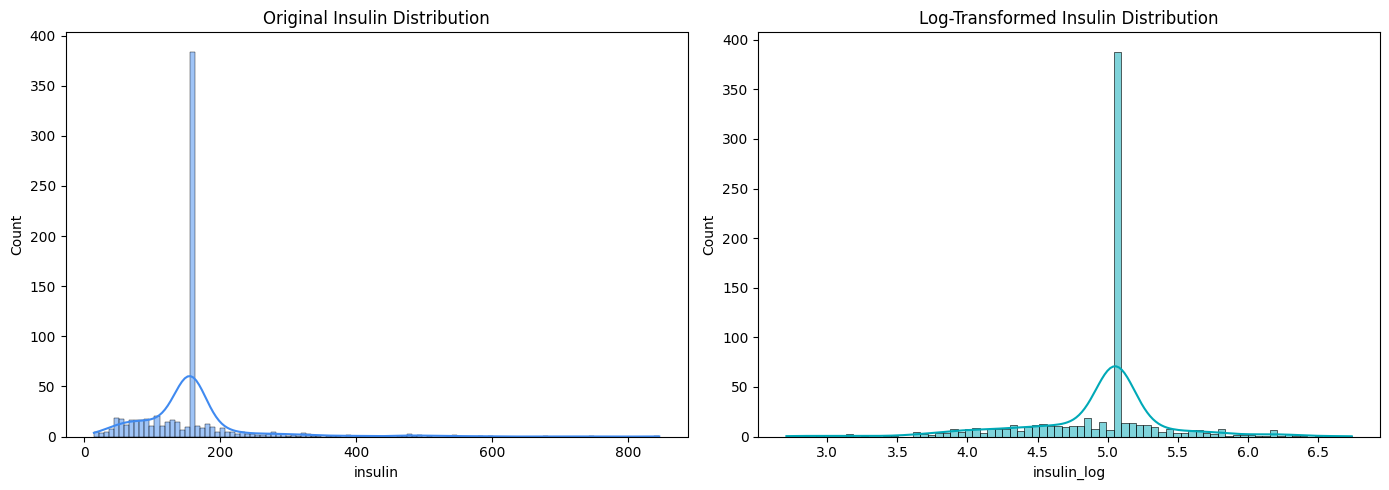

In [20]:
# 시각화를 위해 원본 데이터 복사 (전처리 과정에서 대치된 값 포함)
viz_df = df.copy()

# 로그 변환 적용 (np.log1p 사용) - insulin 컬럼 사용
# log(x)가 아니라 log1p를 사용하는 이유 x가 0일 때 log(0)은 -∞가 되기 때문
viz_df['insulin_log'] = np.log1p(viz_df['insulin'])

# 시각화 비교
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 변환 전 분포
sns.histplot(viz_df['insulin'], ax=ax1, kde=True, color='#408AF0')
ax1.set_title('Original Insulin Distribution')

# 변환 후 분포
sns.histplot(viz_df['insulin_log'], ax=ax2, kde=True, color='#00A9B7')
ax2.set_title('Log-Transformed Insulin Distribution')

plt.tight_layout()
plt.show()